# LELA60342 Week 6 - Evaluation: Receiver Operating Characteristic (ROC) Analysis

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc
import pandas as pd

In [48]:
## Create simulated data
#np.random.seed(10)
w1_center = (2, 4)
w2_center = (4, 2)
batch_size=1000

x = np.zeros((batch_size, 2))
y = np.zeros(batch_size)
for i in range(batch_size):
    if np.random.random() > 0.5:
        x[i] = np.random.normal(loc=w1_center,scale=10)
    else:
        x[i] = np.random.normal(loc=w2_center,scale=10)
        y[i] = 1




In [49]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)
logisticRegr = LogisticRegression()
logisticRegr.fit(x_train, y_train)

LogisticRegression()

In [50]:
precision_recall_fscore_support(y_test,logisticRegr.predict(x_test),average="macro")[2]

0.5997061133490411

<Axes: ylabel='Density'>

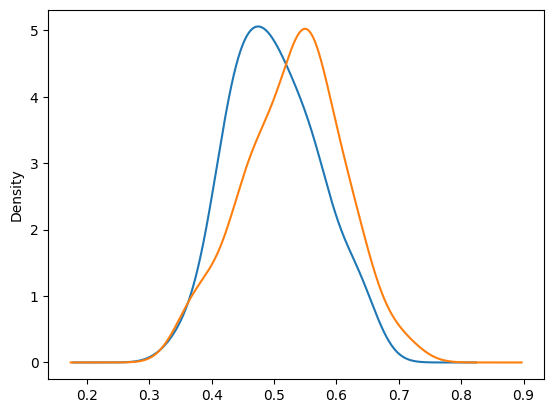

In [51]:
preds_and_labels=pd.DataFrame({"p" : logisticRegr.predict_proba(x_test).T[1], "lab" : y_test})
preds_and_labels[preds_and_labels["lab"] == 0]["p"].plot(kind="density")
preds_and_labels[preds_and_labels["lab"] == 1]["p"].plot(kind="density")

In [52]:
fpr, tpr, thresholds = roc_curve(y_test,logisticRegr.predict_proba(x_test).T[1])

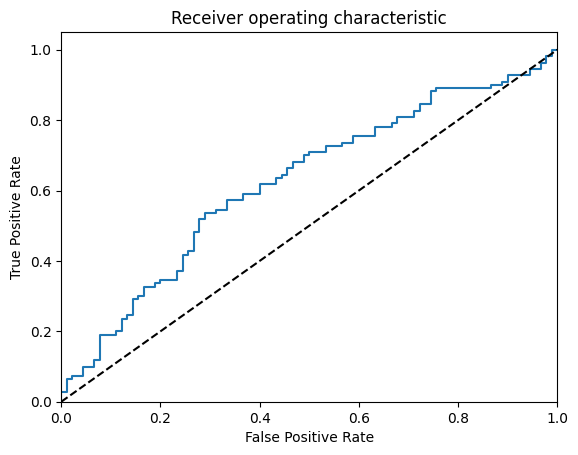

In [53]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.show()

# Area under the curve

In [54]:
auc(fpr, tpr)

np.float64(0.6232323232323232)

# A different dataset

In [55]:
import numpy as np
## Create simulated data
#np.random.seed(10)
w1_center = (2, 8)
w2_center = (8, 2)
batch_size=1000

x = np.zeros((batch_size, 2))
y = np.zeros(batch_size)
for i in range(batch_size):
    if np.random.random() > 0.5:
        x[i] = np.random.normal(loc=w1_center,scale=10)
    else:
        x[i] = np.random.normal(loc=w2_center,scale=10)
        y[i] = 1

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y, test_size=0.2, random_state=10)
logisticRegr = LogisticRegression()
logisticRegr.fit(x_train2, y_train2)

LogisticRegression()

In [57]:
from sklearn.metrics import precision_recall_fscore_support
precision_recall_fscore_support(y_test2,logisticRegr.predict(x_test2),average="macro")[2]

0.6598639455782312

In [58]:
preds_and_labels2=pd.DataFrame({"p" : logisticRegr.predict_proba(x_test2).T[1], "lab" : y_test2})

<Axes: ylabel='Density'>

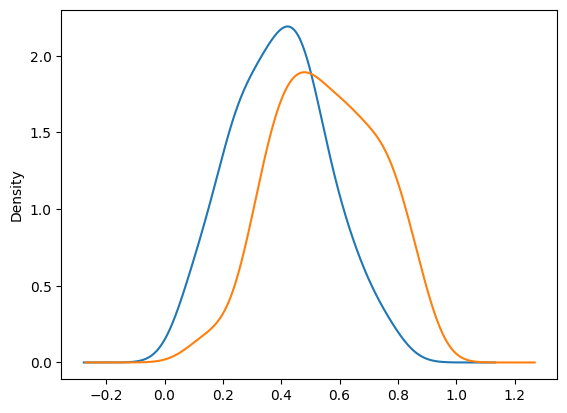

In [59]:
preds_and_labels2[preds_and_labels2["lab"] == 0]["p"].plot(kind="density")
preds_and_labels2[preds_and_labels2["lab"] == 1]["p"].plot(kind="density")


In [60]:
fpr, tpr, thresholds = roc_curve(y_test2,logisticRegr.predict_proba(x_test2).T[1])

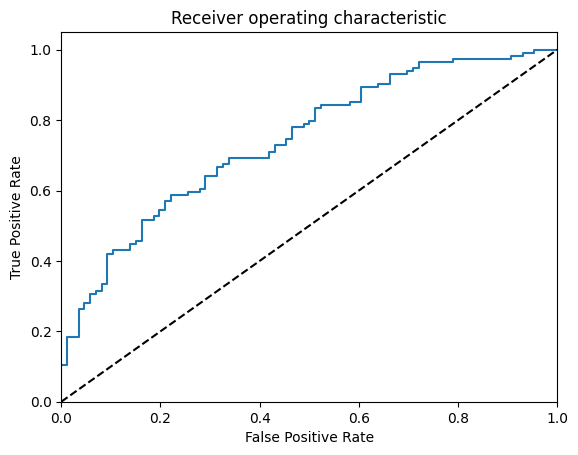

In [61]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.show()

# Area under the curve

In [62]:
auc(fpr, tpr)

np.float64(0.7412280701754385)

### Task 1: Use Bootstrapping to put a 95% confidence interval around the AUC value for this classifier (see the sheet from week 5)

### Task 2: Use 5-fold cross validation to put an interval around the AUC value for this classifier (see the sheet from week 5)